In [89]:
import numpy as np
import pandas as pd
import yfinance as yf
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [90]:
#Data (We use log returns)
data = yf.download('^JKSE', start='2005-01-01', end='2026-01-01', auto_adjust=True)
close = data['Close'].squeeze()
open = data['Open'].squeeze()
returns = np.log(close / close.shift(1)).dropna()

rolling_vol = returns.rolling(20).std()

momentum = returns.rolling(10).mean()

long_momentum =returns.rolling(30).mean()

overnight_gap = np.log(open / close.shift(1))

rolling_max = close.rolling(252).max()
drawdown = np.log(close / rolling_max)

#TESTER MAYBE REMOVE
volume = data['Volume'].squeeze()
volume_ma = volume.rolling(20).mean()
relative_volume = np.log(volume_ma / volume_ma.shift(1))

#Rolling volatility (20 day window) + Momentum (10 day window)
features = pd.DataFrame({
    'returns': returns,
    'volatility': rolling_vol,
    #'momentum': momentum,
    'long_momentum': long_momentum,
    #'volume': relative_volume,
    #'open_close': overnight_gap
    'drawdown': drawdown
}).dropna()

print(f"Data loaded: {len(features)} trading days")
print(features.head(20))

[*********************100%***********************]  1 of 1 completed

Data loaded: 4841 trading days
             returns  volatility  long_momentum  drawdown
Date                                                     
2006-01-13 -0.004648    0.009965       0.004814 -0.008644
2006-01-16 -0.012208    0.010294       0.003968 -0.020851
2006-01-17 -0.018289    0.010590       0.003366 -0.039140
2006-01-18 -0.016354    0.011012       0.002128 -0.055494
2006-01-19  0.030427    0.012336       0.003107 -0.025067
2006-01-20 -0.005847    0.012481       0.002827 -0.030914
2006-01-23 -0.018788    0.013333       0.001383 -0.049702
2006-01-24  0.005893    0.013364       0.001378 -0.043809
2006-01-25  0.018789    0.013781       0.001954 -0.025020
2006-01-26 -0.002820    0.013842       0.001434 -0.027840
2006-01-27  0.002488    0.013842       0.001318 -0.025352
2006-01-30  0.002122    0.013810       0.001624 -0.023230
2006-02-01  0.006772    0.013793       0.002358 -0.016458
2006-02-02  0.002172    0.013659       0.002794 -0.014286
2006-02-03  0.000589    0.012813       0.

In [91]:
split = int(len(features) * 0.7)

#iloc = integer locate
train_features = features.iloc[:split]
test_features = features.iloc[split:]

print(f"Train: {len(train_features)} days")
print(f"Test:  {len(test_features)} days")

Train: 3388 days
Test:  1453 days


In [92]:
# RobustScaler is better for financial data — resistant to outliers like crash days
scaler = RobustScaler()
scaled_train = scaler.fit_transform(train_features)

best_model = None
best_score = -np.inf
n_restarts = 20

for i in range(n_restarts):
    model_candidate = GaussianHMM(
        n_components=3,
        covariance_type="full",
        n_iter=200,
        random_state=i  # different seed each restart
    )
    try:
        model_candidate.fit(scaled_train)
        score = model_candidate.score(scaled_train)
        if score > best_score:
            best_score = score
            best_model = model_candidate
    except Exception as e:
        print(f"Restart {i} failed: {e}")
        continue

model = best_model
print(f"Best log-likelihood: {best_score:.4f}")
print(f"Converged: {model.monitor_.converged}")


Best log-likelihood: -11355.2215
Converged: True


In [93]:
# Scale full dataset using train scaler
all_scaled = scaler.transform(features)
states = model.predict(all_scaled)

# Label states by mean return
state_means = [features['returns'].values[states == s].mean() for s in range(3)]
sorted_states = np.argsort(state_means)
state_labels = {
    sorted_states[0]: 'Bear',
    sorted_states[1]: 'Neutral',
    #sorted_states[2]: 'Weak Bull',
    sorted_states[2]: 'Bull'
}
colors = {
    sorted_states[0]: '#d62728',   # red
    sorted_states[1]: '#ffbb78',   # light orange
    #sorted_states[2]: '#aec7e8',   # light blue
    sorted_states[2]: "#3c902b",   # green
}

print("State means:", {state_labels[s]: f"{state_means[s]:.4f}" for s in range(3)})

State means: {'Bull': '0.0013', 'Neutral': '-0.0000', 'Bear': '-0.0005'}


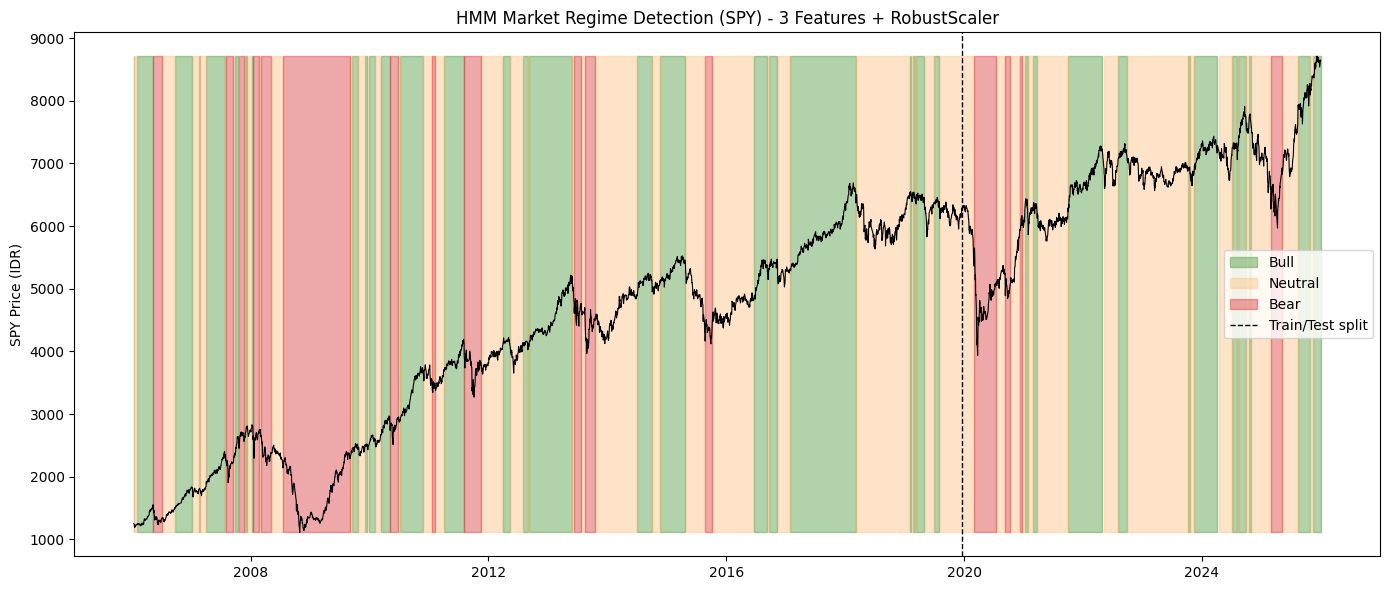

In [94]:
plt.figure(figsize=(14, 6))

plt.plot(features.index, close.loc[features.index], color='black', linewidth=0.8, zorder=3)

for state in range(3):
    mask = (states == state)
    plt.fill_between(features.index,
                     close.loc[features.index].min(),
                     close.loc[features.index].max(),
                     where=mask, alpha=0.4, color=colors[state],
                     label=state_labels[state], zorder=1)

split_date = features.index[split]
plt.axvline(split_date, color='black', linestyle='--', linewidth=1, label='Train/Test split')
plt.legend()
plt.title('HMM Market Regime Detection (SPY) - 3 Features + RobustScaler')
plt.ylabel('SPY Price (IDR)')
plt.tight_layout()
plt.show()

In [95]:
for state in range(3):
    regime_returns = features['returns'].values[states == state]
    print(f"{state_labels[state]:8s} | Mean: {regime_returns.mean():.4f} | Std: {regime_returns.std():.4f} | Days: {len(regime_returns)}")

Bull     | Mean: 0.0013 | Std: 0.0075 | Days: 1829
Neutral  | Mean: -0.0000 | Std: 0.0099 | Days: 2209
Bear     | Mean: -0.0005 | Std: 0.0228 | Days: 803


In [96]:
# Check if test set regimes look sane vs train set
test_states = model.predict(scaler.transform(test_features))

print("Train regime distribution:")
for state in range(3):
    pct = (states[:split] == state).sum() / split * 100
    print(f"  {state_labels[state]:12s}: {pct:.1f}%")

print("\nTest regime distribution:")
for state in range(3):
    pct = (test_states == state).sum() / len(test_states) * 100
    print(f"  {state_labels[state]:12s}: {pct:.1f}%")

Train regime distribution:
  Bull        : 40.4%
  Neutral     : 40.6%
  Bear        : 19.0%

Test regime distribution:
  Bull        : 31.7%
  Neutral     : 57.4%
  Bear        : 10.9%


In [97]:
results = []

for n in range(2, 7):
    m = GaussianHMM(n_components=n, covariance_type="full", n_iter=200, random_state=42)
    m.fit(scaled_train)
    
    aic = m.aic(all_scaled)
    bic = m.bic(all_scaled)
    results.append((n, aic, bic))
    print(f"n={n} | AIC: {aic:.2f} | BIC: {bic:.2f} | Converged: {m.monitor_.converged}")

n=2 | AIC: 39172.02 | BIC: 39373.05 | Converged: True
n=3 | AIC: 32005.64 | BIC: 32329.88 | Converged: True
n=4 | AIC: 34200.09 | BIC: 34660.51 | Converged: True
n=5 | AIC: 28475.57 | BIC: 29085.15 | Converged: True
n=6 | AIC: 25326.72 | BIC: 26098.42 | Converged: True


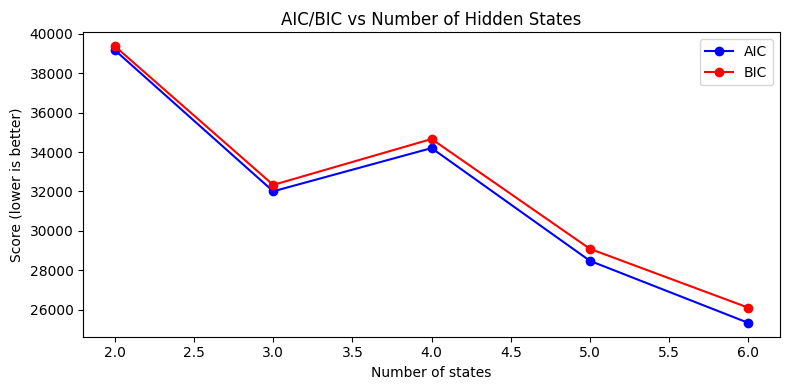

In [98]:
ns   = [r[0] for r in results]
aics = [r[1] for r in results]
bics = [r[2] for r in results]

plt.figure(figsize=(8, 4))
plt.plot(ns, aics, 'o-', label='AIC', color='blue')
plt.plot(ns, bics, 'o-', label='BIC', color='red')
plt.xlabel('Number of states')
plt.ylabel('Score (lower is better)')
plt.title('AIC/BIC vs Number of Hidden States')
plt.legend()
plt.tight_layout()
plt.show()

In [99]:
# State persistence — average days spent in each regime before switching
def compute_persistence(states, state_labels):
    persistence = {label: [] for label in state_labels.values()}
    
    current_state = states[0]
    count = 1
    
    for i in range(1, len(states)):
        if states[i] == current_state:
            count += 1
        else:
            persistence[state_labels[current_state]].append(count)
            current_state = states[i]
            count = 1
    
    # Don't forget the last run
    persistence[state_labels[current_state]].append(count)
    
    print("State Persistence (avg consecutive days per regime):")
    for label, runs in persistence.items():
        print(f"{label:12s} | Avg: {np.mean(runs):.1f} days | Max: {np.max(runs)} days | Transitions: {len(runs)}")

compute_persistence(states, state_labels)

State Persistence (avg consecutive days per regime):
Bear         | Avg: 50.2 days | Max: 270 days | Transitions: 16
Neutral      | Avg: 47.0 days | Max: 248 days | Transitions: 47
Bull         | Avg: 49.4 days | Max: 268 days | Transitions: 37


In [100]:
#log-likelihood on train vs test set
scaled_test = scaler.transform(test_features)

train_score = model.score(scaled_train) / len(scaled_train)
test_score = model.score(scaled_test) / len(scaled_test)

print(f"Train log-likelihood (per sample): {train_score:.4f}")
print(f"Test log-likelihood (per sample): {test_score:.4f}")
print(f"Difference: {abs(train_score - test_score):.4f}")

if abs(train_score - test_score) < 0.5:
    print("\nModel generalizes well - train and test scores are close")
elif test_score < train_score - 0.5:
    print("\nPossible overfitting — test score is significantly lower than train")

Train log-likelihood (per sample): -3.3516
Test log-likelihood (per sample): -3.1177
Difference: 0.2339

Model generalizes well - train and test scores are close


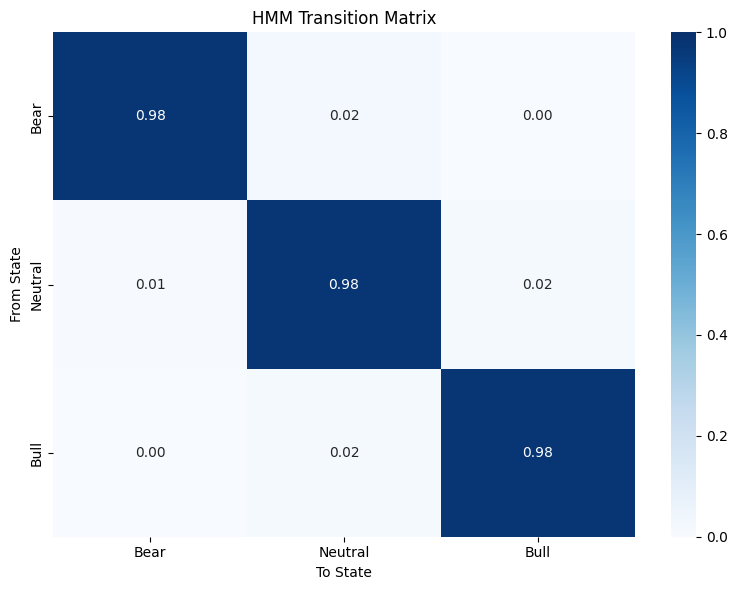

In [101]:
import seaborn as sns

# Get transition matrix and reorder by our state labels
# Build ordered label list from sorted_states
ordered_labels = [state_labels[sorted_states[i]] for i in range(3)]

# Reorder transition matrix rows/cols to match our labeling
transmat = model.transmat_

# Map sorted state indices to transition matrix
idx = [sorted_states[i] for i in range(3)]
reordered = transmat[np.ix_(idx, idx)]

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(reordered, 
            annot=True, 
            fmt='.2f',
            xticklabels=ordered_labels,
            yticklabels=ordered_labels,
            cmap='Blues',
            vmin=0, vmax=1)

plt.title('HMM Transition Matrix')
plt.ylabel('From State')
plt.xlabel('To State')
plt.tight_layout()
plt.show()

In [102]:
# Regime Prediction using forward algorithm + transition matrix
def predict_regime(model, recent_data, scaler, state_labels, sorted_states, k=1):
    # Scale the recent data
    scaled = scaler.transform(recent_data)

    # Forward algorithm - get current state probability distribution
    # model.predict_proba() returns P(state|observations) for each timestep
    state_probs = model.predict_proba(scaled)

    # Take the last timestep's probabilities as current state
    current_probs = state_probs[-1]

    # Project k steps ahead using the transition matrix
    future_probs = current_probs @ np.linalg.matrix_power(model.transmat_, k)

    #Map to labels
    predicted_state = np.argmax(future_probs)
    predicted_label = state_labels[predicted_state]

    print(f"Prediction {k} day(s) ahead:")
    print(f"Predicted regime: {predicted_label}")
    print(f"\nFull probability distribution:")
    for i in range(3):
        label = state_labels[sorted_states[i]]
        prob = future_probs[sorted_states[i]]
        print(f"  {label:.12s}: {prob:.4f} ({prob*100:.4f}%)")

    return predicted_label, future_probs

#Use last 60 days as recent data
recent_data = features.iloc[-60:]

#Predict 1, 5, 10 days ahead
for k in [1, 5, 10]:
    print(f"{'='*40}")
    predict_regime(model, recent_data, scaler, state_labels, sorted_states, k=k)
    print()

Prediction 1 day(s) ahead:
Predicted regime: Bull

Full probability distribution:
  Bear: 0.0036 (0.3650%)
  Neutral: 0.0161 (1.6069%)
  Bull: 0.9803 (98.0281%)

Prediction 5 day(s) ahead:
Predicted regime: Bull

Full probability distribution:
  Bear: 0.0177 (1.7721%)
  Neutral: 0.0737 (7.3674%)
  Bull: 0.9086 (90.8605%)

Prediction 10 day(s) ahead:
Predicted regime: Bull

Full probability distribution:
  Bear: 0.0341 (3.4126%)
  Neutral: 0.1338 (13.3823%)
  Bull: 0.8321 (83.2051%)



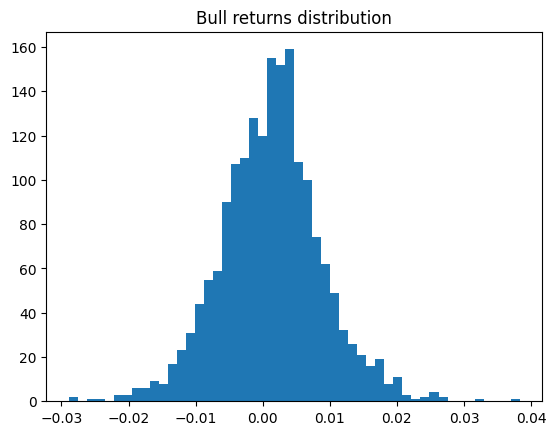

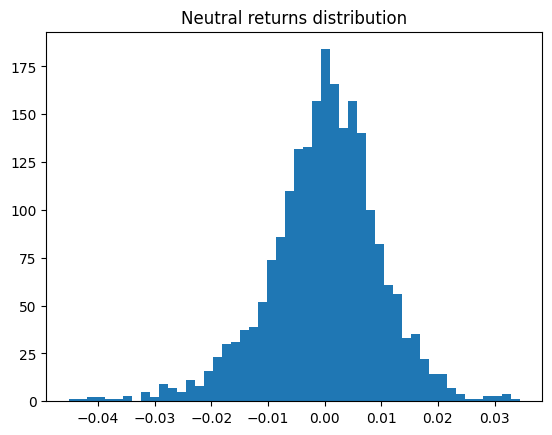

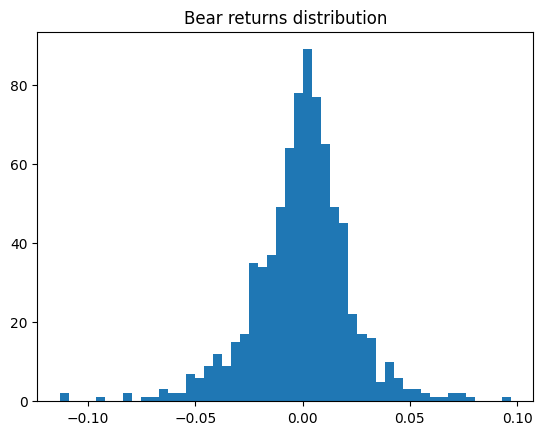

In [103]:
# Check if returns within each state look Gaussian
for state in range(3):
    regime_returns = features['returns'].values[states == state]
    plt.hist(regime_returns, bins=50)
    plt.title(f'{state_labels[state]} returns distribution')
    plt.show()

In [104]:
def walk_forward_hmm(features, n_splits=5, n_components=3):
    total = len(features)
    fold_size = total // (n_splits + 1)
    
    results = []
    for i in range(1, n_splits + 1):
        train = features.iloc[:fold_size * i]
        test = features.iloc[fold_size * i : fold_size * (i + 1)]
        
        scaler = RobustScaler()
        scaled_train = scaler.fit_transform(train)
        scaled_test = scaler.transform(test)
        
        model = GaussianHMM(n_components=n_components, 
                           covariance_type="full", 
                           n_iter=200, 
                           random_state=42)
        model.fit(scaled_train)
        
        train_score = model.score(scaled_train) / len(scaled_train)
        test_score = model.score(scaled_test) / len(scaled_test)
        
        print(f"Fold {i} | Train: {len(train)} days | "
              f"Test: {len(test)} days | "
              f"Train LL: {train_score:.4f} | "
              f"Test LL: {test_score:.4f} | "
              f"Gap: {abs(train_score-test_score):.4f}")
        results.append((train_score, test_score))
    
    avg_gap = np.mean([abs(r[0]-r[1]) for r in results])
    print(f"\nAverage gap across folds: {avg_gap:.4f}")
    return results

results = walk_forward_hmm(features, n_splits=5, n_components=3)

Fold 1 | Train: 806 days | Test: 806 days | Train LL: -2.5317 | Test LL: -2.7887 | Gap: 0.2571
Fold 2 | Train: 1612 days | Test: 806 days | Train LL: -3.4237 | Test LL: -3.0798 | Gap: 0.3439
Fold 3 | Train: 2418 days | Test: 806 days | Train LL: -3.2514 | Test LL: -2.0666 | Gap: 1.1848
Fold 4 | Train: 3224 days | Test: 806 days | Train LL: -3.2849 | Test LL: -3.5136 | Gap: 0.2287
Fold 5 | Train: 4030 days | Test: 806 days | Train LL: -3.4201 | Test LL: -2.7115 | Gap: 0.7086

Average gap across folds: 0.5446


In [105]:
# Get state-dependent parameters from the fitted model
decoded_states = states  # already computed from your predict() call

# Compute pseudo-residuals
pseudo_residuals = np.zeros(len(features))

for t in range(len(features)):
    s = decoded_states[t]
    
    # Get the mean and variance for this state
    # model.means_ shape: (n_states, n_features)
    # model.covars_ shape: (n_states, n_features, n_features) for full covariance
    mean = model.means_[s, 0]  # first feature (returns)
    std = np.sqrt(model.covars_[s, 0, 0])  # variance of first feature
    
    # Use the scaled version of returns (first features)
    obs = all_scaled[t, 0]

    # Step 1: compute percentile of this observation under its state distribution
    percentile = stats.norm.cdf(obs, loc=mean, scale=std)
    
    # Step 2: clip to avoid log(0) issues at the boundaries
    percentile = np.clip(percentile, 1e-6, 1 - 1e-6)
    
    # Step 3: convert percentile to standard normal quantile
    pseudo_residuals[t] = stats.norm.ppf(percentile)

print("Pseudo-residuals computed")
print(f"Mean: {pseudo_residuals.mean():.4f} (should be ~0)")
print(f"Std:  {pseudo_residuals.std():.4f} (should be ~1)")

Pseudo-residuals computed
Mean: -0.0081 (should be ~0)
Std:  0.9637 (should be ~1)


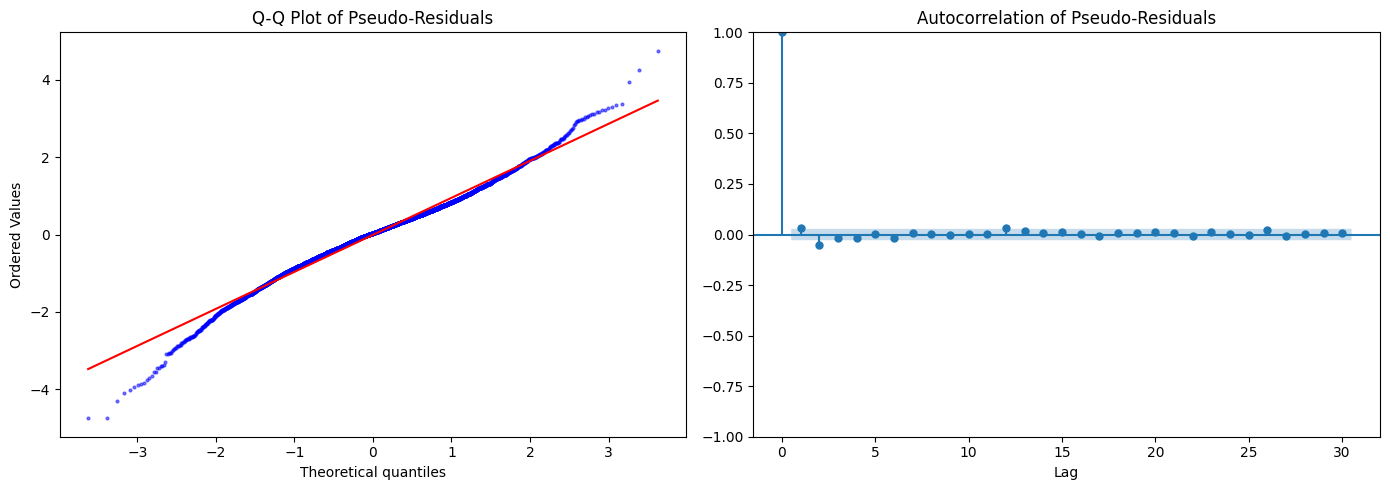

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q-Q Plot
stats.probplot(pseudo_residuals, dist="norm", plot=axes[0])
axes[0].set_title("Q-Q Plot of Pseudo-Residuals")
axes[0].get_lines()[0].set(markersize=2, alpha=0.5)

# Autocorrelation Plot
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(pseudo_residuals, lags=30, ax=axes[1], alpha=0.05)
axes[1].set_title("Autocorrelation of Pseudo-Residuals")
axes[1].set_xlabel("Lag")

plt.tight_layout()
plt.show()

In [107]:
# HHMM Step 1: Chunk daily returns into 20 day blocks

block_size = 30

# How many complete blocks can we make?
n_blocks = len(features) // block_size

# Trim features to only inlcude complete blocks
# e.g. if we have 4523 days and block size=20, we use 4520 days (226 complete blocks)
features_trimmed = features.iloc[:n_blocks * block_size]

print(f"Total trading days: {len(features)}")
print(f"Block size: {block_size} days")
print(f"Number of complete blocks: {n_blocks}")
print(f"Days used: {len(features_trimmed)}")
print(f"Days dropped: {len(features) - len(features_trimmed)}")

Total trading days: 4841
Block size: 30 days
Number of complete blocks: 161
Days used: 4830
Days dropped: 11


In [108]:
# HHMMM Step 2: Compute coarse-scale observation (20-day average returns)

coarse_obs = np.zeros((n_blocks, 4))

for i in range(n_blocks):
    block = features_trimmed.iloc[i * block_size : (i + 1) * block_size]
    coarse_obs[i, 0] = block['returns'].mean()
    coarse_obs[i, 1] = block['volatility'].mean()
    coarse_obs[i, 2] = block['long_momentum'].mean()
    coarse_obs[i, 3] = block['drawdown'].mean()

print(f"Coarse observation shape: {coarse_obs.shape}")
print(f"\nFeature means across all blocks:")
print(f"Mean: {coarse_obs.mean():.6f}")
print(f"Std: {coarse_obs.std():.6f}")
print(f"Min: {coarse_obs.min():.6f}")
print(f"Max: {coarse_obs.max():.6f}")

Coarse observation shape: (161, 4)

Feature means across all blocks:
Mean: -0.019175
Std: 0.075954
Min: -0.795211
Max: 0.043970


In [109]:
# HHMM Step 3: Fit coarse-scale HMM (3 states on 20 day average returns)

# Scale coarse observations
coarse_scaler = RobustScaler()
coarse_scaled = coarse_scaler.fit_transform(coarse_obs) 

#Fit with restarts
best_coarse_model = None
best_coarse_score = -np.inf

for i in range(20):
    candidate = GaussianHMM(n_components=3, covariance_type='full', n_iter=200,random_state=i)
    try:
        candidate.fit(coarse_scaled)
        score = candidate.score(coarse_scaled)
        if score > best_coarse_score:
            best_coarse_score = score
            best_coarse_model = candidate
    except:
        continue

coarse_states = best_coarse_model.predict(coarse_scaled)

# Label coarse states by mean return
coarse_state_means = [coarse_obs[coarse_states == s, 0].mean() for s in range(3)]
coarse_sorted = np.argsort(coarse_state_means)
coarse_labels = {
    coarse_sorted[0]: 'Bear',
    coarse_sorted[1]: 'Neutral',
    coarse_sorted[2]: 'Bull' 
}

print(f"Coarse model log-likelihood: {best_coarse_score:.4f}")
print(f"Converged: {best_coarse_model.monitor_.converged}")
print(f"\nCoarse state distribution:")
for s in range(3):
    pct = (coarse_states == s).sum() / n_blocks * 100
    print(f"  {coarse_labels[s]:8s}: {pct:.1f}% ({(coarse_states == s).sum()} blocks)")

Model is not converging.  Current: -679.2667174153856 is not greater than -655.4983831049539. Delta is -23.768334310431783


Coarse model log-likelihood: -571.1099
Converged: True

Coarse state distribution:
  Neutral : 50.9% (82 blocks)
  Bear    : 15.5% (25 blocks)
  Bull    : 33.5% (54 blocks)


In [110]:
# HHMM Step 4: Fit fine-scale HMMs (one per coarse state)

fine_scaler = RobustScaler()
#all_daily_scaled = fine_scaler.fit_transform(features_trimmed[['returns', 'volatility', 'momentum', 'drawdown']])
all_daily_scaled_fine = fine_scaler.fit_transform(features_trimmed[['returns']]) 

fine_models = {}

for coarse_state in range(3):
    # Find which blocks belong to this coarse state
    block_indices = np.where(coarse_states == coarse_state)[0]

    #Collect all daily observations from those blocks
    daily_obs = []
    for block_idx in block_indices:
        start = block_idx * block_size
        end = start + block_size
        daily_obs.append(all_daily_scaled_fine[start:end])

    daily_obs = np.vstack(daily_obs)

    #Fit with restarts
    best_fine = None
    best_fine_score = -np.inf

    for i in range(20):
        candidate = GaussianHMM(n_components=2, covariance_type='full', n_iter=200, random_state=i)
        try:
            candidate.fit(daily_obs)
            score = candidate.score(daily_obs)
            if score > best_fine_score:
                best_fine_score = score
                best_fine = candidate
        except:
            continue

    fine_models[coarse_state] = best_fine
    label = coarse_labels[coarse_state]
    print(f"{label:8s} | Fine model LL: {best_fine_score:.4f} | Converged: {best_fine.monitor_.converged} | Days: {len(daily_obs)}")

Neutral  | Fine model LL: -2450.5173 | Converged: True | Days: 2460
Bear     | Fine model LL: -1496.7673 | Converged: True | Days: 750
Bull     | Fine model LL: -2239.2957 | Converged: True | Days: 1620


In [111]:
# HHMM Step 5: Decode fine-scale states for every day

fine_states = np.zeros(len(features_trimmed), dtype=int)

for coarse_state in range(3):
    block_indices = np.where(coarse_states == coarse_state)[0]

    for block_idx in block_indices:
        start = block_idx * block_size
        end = start + block_size

        block_data = all_daily_scaled_fine[start:end]
        decoded = fine_models[coarse_state].predict(block_data)
        fine_states[start:end] = decoded


# Label fine states as High/Low vol per coarse state
fine_labels = {}

for coarse_state in range(3):
    block_indices = np.where(coarse_states == coarse_state)[0]
    daily_indices = []
    for block_idx in block_indices:
        daily_indices.extend(range(block_idx * block_size, (block_idx + 1) * block_size))

    # Which state has higher volatility?
    vol_by_fine_state = [
        features_trimmed['volatility'].values[daily_indices][fine_states[daily_indices] == fs].mean() for fs in range(2)
    ]
    high_vol_state = np.argmax(vol_by_fine_state)
    fine_labels[coarse_state] = {
        high_vol_state: 'High Vol',
        1 - high_vol_state: 'Low Vol'
    }

print("Fine state labeling per coarse state:")
for coarse_state in range(3):
    print(f"  {coarse_labels[coarse_state]:8s} -> {fine_labels[coarse_state]}")

Fine state labeling per coarse state:
  Neutral  -> {np.int64(0): 'High Vol', np.int64(1): 'Low Vol'}
  Bear     -> {np.int64(1): 'High Vol', np.int64(0): 'Low Vol'}
  Bull     -> {np.int64(1): 'High Vol', np.int64(0): 'Low Vol'}


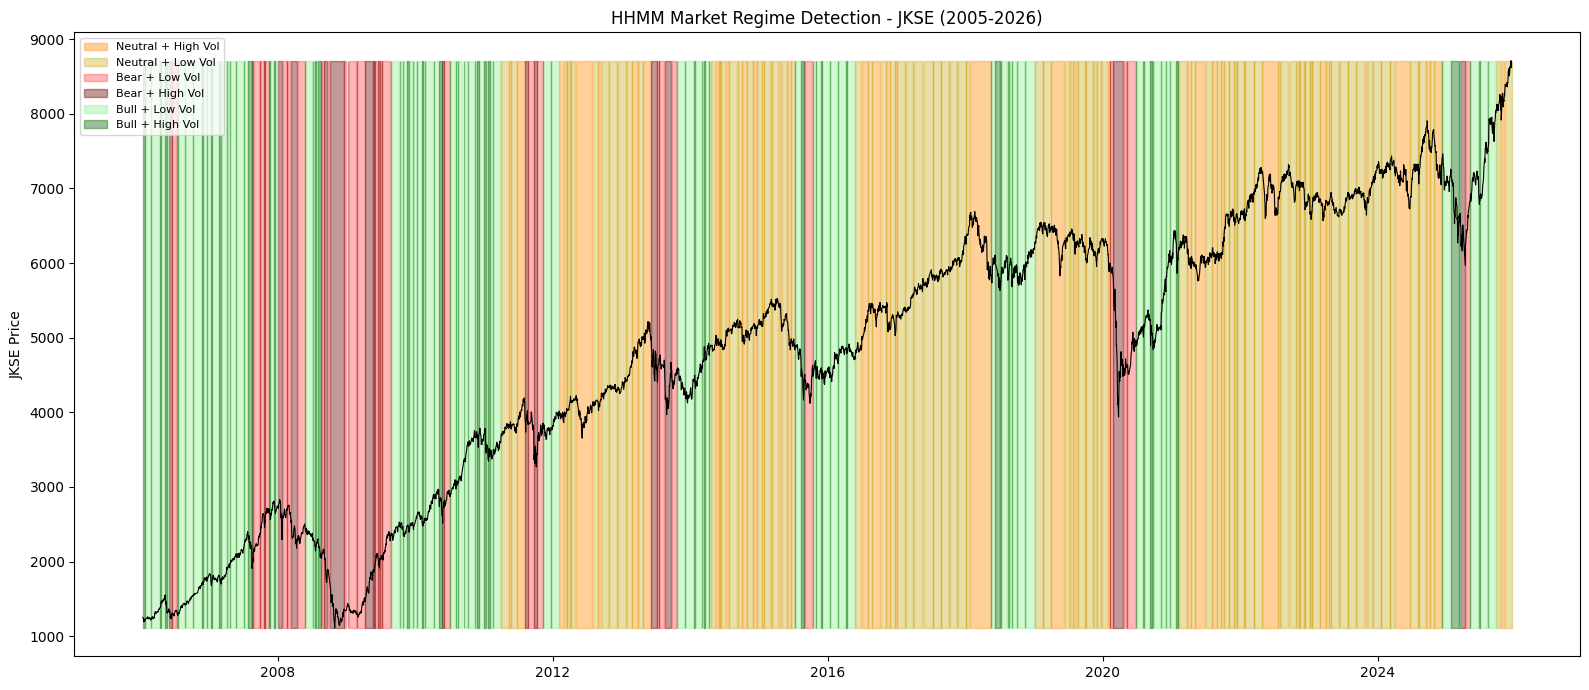

In [112]:
# HHMM Step 6: Combine coarse and fine states, then visualize

# Map each day to its coarse state (expand block-level to day-level)
daily_coarse_states = np.zeros(len(features_trimmed), dtype=int)
for block_idx in range(n_blocks):
    start = block_idx * block_size
    end = start + block_size
    daily_coarse_states[start:end] = coarse_states[block_idx]

# Create combined labels and colors for all 6 combinations
combined_labels = {}
combined_colors = {
    ('Bear', 'High Vol'): "#680000",    # dark red
    ('Bear', 'Low Vol'):  "#FF4C4C",    # light red
    ('Neutral', 'High Vol'): '#FF8C00', # dark orange
    ('Neutral', 'Low Vol'):  "#C8B02A", # yellow
    ('Bull', 'High Vol'): '#006400',    # dark green
    ('Bull', 'Low Vol'):  '#90EE90',    # light green
}

# Plot
close_trimmed = data['Close'].squeeze().loc[features_trimmed.index]

plt.figure(figsize=(16,7))
plt.plot(features_trimmed.index, close_trimmed, color='black', linewidth=0.8, zorder=3)

for coarse_state in  range(3):
    for fine_state in range(2):
        mask = (daily_coarse_states == coarse_state) & (fine_states == fine_state)
        coarse_name = coarse_labels[coarse_state]
        fine_name = fine_labels[coarse_state][fine_state]
        color = combined_colors[(coarse_name, fine_name)]
        label = f"{coarse_name} + {fine_name}"

        plt.fill_between(features_trimmed.index,
                         close_trimmed.min(),
                         close_trimmed.max(),
                         where=mask,
                         alpha=0.4,
                         color=color,
                         label=label,
                         zorder=1)
        
plt.legend(loc='upper left', fontsize=8)
plt.title('HHMM Market Regime Detection - JKSE (2005-2026)')
plt.ylabel('JKSE Price')
plt.tight_layout()
plt.show()

In [113]:
for coarse_state in range(3):
    for fine_state in range(2):
        mask = (daily_coarse_states == coarse_state) & (fine_states == fine_state)
        ret = features_trimmed['returns'].values[mask]
        vol = features_trimmed['volatility'].values[mask]
        coarse_name = coarse_labels[coarse_state]
        fine_name = fine_labels[coarse_state][fine_state]
        print(f"{coarse_name:8s} + {fine_name:8s} | Mean return: {ret.mean():.5f} | Vol: {vol.mean():.5f} | Days: {mask.sum()}")

Neutral  + High Vol | Mean return: -0.00042 | Vol: 0.00841 | Days: 850
Neutral  + Low Vol  | Mean return: 0.00069 | Vol: 0.00685 | Days: 1610
Bear     + Low Vol  | Mean return: 0.00186 | Vol: 0.01881 | Days: 445
Bear     + High Vol | Mean return: -0.00273 | Vol: 0.02448 | Days: 305
Bull     + Low Vol  | Mean return: 0.00206 | Vol: 0.01045 | Days: 1344
Bull     + High Vol | Mean return: -0.00579 | Vol: 0.01275 | Days: 276


In [114]:
# ============================================================
# WALK-FORWARD VALIDATION WITH PERIODIC RE-FITTING
# ============================================================


from sklearn.preprocessing import RobustScaler
from hmmlearn.hmm import GaussianHMM
import numpy as np

min_train_days = 252 * 3  # minimum 3 years to start
refit_every = 252          # refit every year
n_states = 3

all_wf_states = np.full(len(features), -1, dtype=int)  # -1 = not yet predicted
all_wf_labels = {}

fold = 1
cursor = min_train_days

while cursor < len(features):
    train = features.iloc[:cursor]
    test_end = min(cursor + refit_every, len(features))
    test = features.iloc[cursor:test_end]
    
    # Scale using only train data
    wf_scaler = RobustScaler()
    scaled_train = wf_scaler.fit_transform(train)
    scaled_test = wf_scaler.transform(test)
    
    # Fit with restarts
    best_model = None
    best_score = -np.inf
    for i in range(20):
        candidate = GaussianHMM(n_components=n_states, covariance_type="full",
                                n_iter=200, random_state=i)
        try:
            candidate.fit(scaled_train)
            score = candidate.score(scaled_train)
            if score > best_score:
                best_score = score
                best_model = candidate
        except:
            continue
    
    # Predict on test set
    test_states = best_model.predict(scaled_test)
    
    # Label states by mean return
    state_means = [train['returns'].values[best_model.predict(scaled_train) == s].mean() 
                   for s in range(n_states)]
    sorted_states = np.argsort(state_means)
    fold_labels = {
        sorted_states[0]: 'Bear',
        sorted_states[1]: 'Neutral',
        sorted_states[2]: 'Bull'
    }
    
    # Store predictions
    all_wf_states[cursor:test_end] = test_states
    all_wf_labels[fold] = fold_labels
    
    train_years = len(train) / 252
    per_sample_ll = best_score / len(train)
    print(f"Fold {fold:2d} | Train: {len(train):4d} days ({train_years:.1f}y) | "
      f"Test: {len(test):3d} days | "
      f"LL/sample: {per_sample_ll:.4f} | Converged: {best_model.monitor_.converged}")
    
    cursor = test_end
    fold += 1

print(f"\nTotal out-of-sample days predicted: {(all_wf_states != -1).sum()}")
print(f"Days not predicted (initial training period): {(all_wf_states == -1).sum()}")

Fold  1 | Train:  756 days (3.0y) | Test: 252 days | LL/sample: -2.4339 | Converged: True


Model is not converging.  Current: -3059.4886106575786 is not greater than -3059.487371760037. Delta is -0.0012388975414978631


Fold  2 | Train: 1008 days (4.0y) | Test: 252 days | LL/sample: -2.7541 | Converged: True
Fold  3 | Train: 1260 days (5.0y) | Test: 252 days | LL/sample: -2.8040 | Converged: True
Fold  4 | Train: 1512 days (6.0y) | Test: 252 days | LL/sample: -3.0280 | Converged: True
Fold  5 | Train: 1764 days (7.0y) | Test: 252 days | LL/sample: -3.2594 | Converged: True
Fold  6 | Train: 2016 days (8.0y) | Test: 252 days | LL/sample: -3.1018 | Converged: True
Fold  7 | Train: 2268 days (9.0y) | Test: 252 days | LL/sample: -3.2694 | Converged: True
Fold  8 | Train: 2520 days (10.0y) | Test: 252 days | LL/sample: -3.2007 | Converged: True
Fold  9 | Train: 2772 days (11.0y) | Test: 252 days | LL/sample: -3.3584 | Converged: True
Fold 10 | Train: 3024 days (12.0y) | Test: 252 days | LL/sample: -3.2265 | Converged: True
Fold 11 | Train: 3276 days (13.0y) | Test: 252 days | LL/sample: -3.3048 | Converged: True
Fold 12 | Train: 3528 days (14.0y) | Test: 252 days | LL/sample: -3.3597 | Converged: True
Fold 

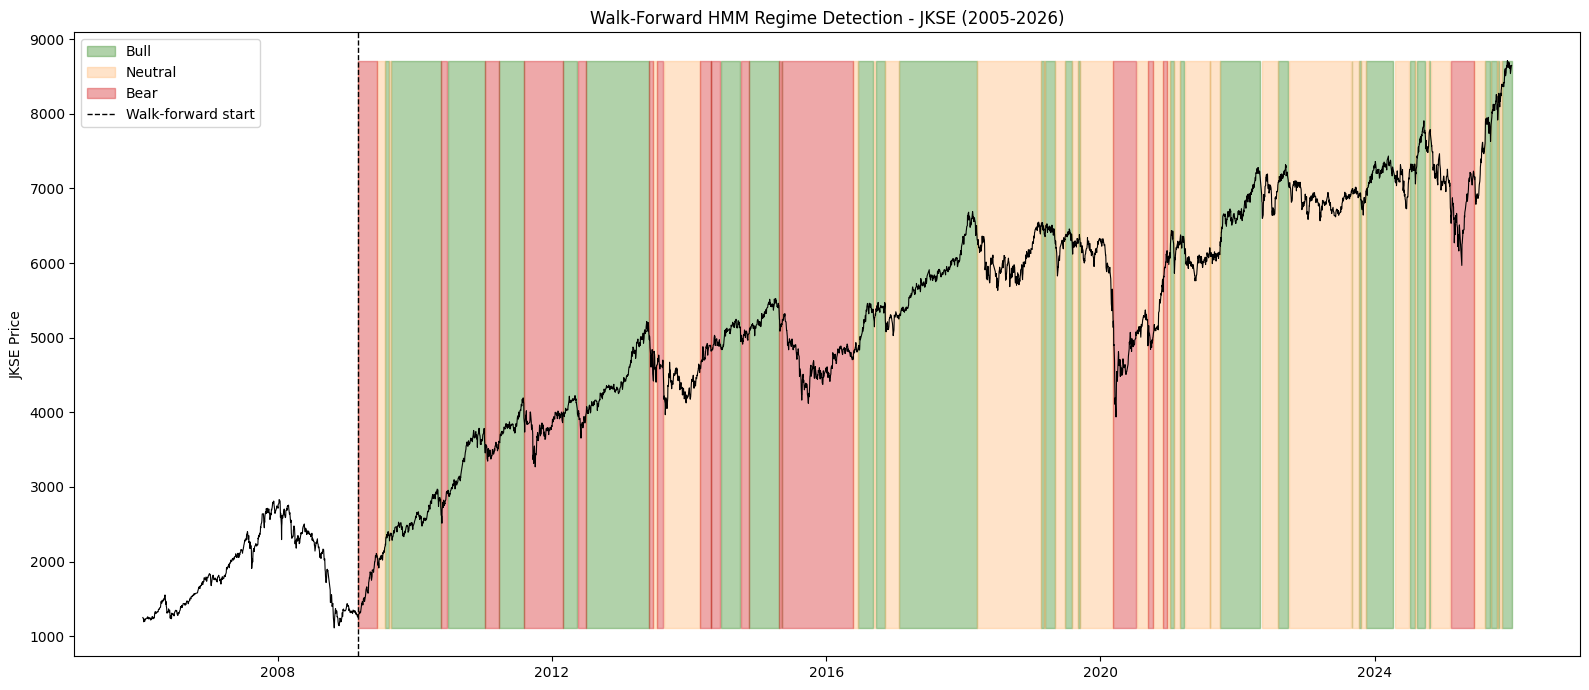

In [115]:
fig, ax = plt.subplots(figsize=(16, 7))

close_wf = data['Close'].squeeze().loc[features.index]
ax.plot(features.index, close_wf, color='black', linewidth=0.8, zorder=3)

colors = {'Bear': '#d62728', 'Neutral': '#ffbb78', 'Bull': '#3c902b'}

# Build a day-level label array using each fold's own mapping
wf_regime_labels = np.full(len(features), '', dtype=object)

cursor = min_train_days
for fold_num in range(1, len(all_wf_labels) + 1):
    test_end = min(cursor + refit_every, len(features))
    fold_labels = all_wf_labels[fold_num]
    
    for day_idx in range(cursor, test_end):
        state = all_wf_states[day_idx]
        wf_regime_labels[day_idx] = fold_labels.get(state, 'Unknown')
    
    cursor = test_end

# Plot each regime
for regime in ['Bull', 'Neutral', 'Bear']:
    mask = wf_regime_labels == regime
    ax.fill_between(features.index,
                    close_wf.min(),
                    close_wf.max(),
                    where=mask,
                    alpha=0.4,
                    color=colors[regime],
                    label=regime,
                    zorder=1)

ax.axvline(features.index[756], color='black', linestyle='--',
           linewidth=1, label='Walk-forward start')

ax.legend()
ax.set_title('Walk-Forward HMM Regime Detection - JKSE (2005-2026)')
ax.set_ylabel('JKSE Price')
plt.tight_layout()
plt.show()

In [116]:
print("Walk-Forward Regime Statistics:")
for regime in ['Bull', 'Neutral', 'Bear']:
    mask = wf_regime_labels == regime
    ret = features['returns'].values[mask]
    if len(ret) > 0:
        print(f"{regime:8s} | Mean return: {ret.mean():.5f} | "
              f"Std: {ret.std():.5f} | Days: {mask.sum()}")

Walk-Forward Regime Statistics:
Bull     | Mean return: 0.00094 | Std: 0.00782 | Days: 1760
Neutral  | Mean return: 0.00000 | Std: 0.01014 | Days: 1424
Bear     | Mean return: 0.00031 | Std: 0.01583 | Days: 901
